# PT(압력)가 g_s_SV(목표 유량)와 관계가 있는가 — 선형 vs 2차## 확인하려는 것`Scale_Out___PT`(압력)가 `g_s_SV`(목표 유량)를 따라간다고 흔히 가정하는데, 이게**항상** 성립하는 게 아니라 **`Scale_Out___FT`(실제 유량)가 목표에 잘 맞을 때만**관계가 뚜렷하게 나타나는 게 아니냐는 걸 확인하고 싶은 것이다. 증압 중이거나 유량이목표를 못 맞추고 있을 때는 PT가 SV와 무관하게 흔들릴 수 있으니, **오차율이 작은틱만 모아서** SV 구간별 PT 값을 본다.(처음엔 "정비례"인지를 물었는데, 그건 질문을 잘못 잡은 것이었다 — 여기서 보는 건**선형 관계가 있는지**이고, 추가로 **2차(제곱) 관계가 더 잘 맞는지**까지 같이 본다.설명서(`Cycle_Features_설명서.ipynb`)의 `DeltaP_over_Q` 설명에 "노즐 같은 좁은 구멍은Δp ∝ Q² 관계"라는 언급이 있어서, 2차 관계도 확인해볼 근거가 있다.)오차율 기준은 **±5%와 ±3% 둘 다** 써서 비교한다.## 주의 — 사이클 초반의 "잠깐 들어왔다 나가는" 틱 (bounce-back)증압 도중에 오차율이 우연히 한두 틱 밴드 안에 들어왔다가 바로 다시 나가는 경우가있다(`안정구간_정착시간_검증.ipynb` §3에서 실제 사례로 확인한 것과 같은 현상). 이런틱을 "오차율이 작은 케이스"에 잘못 포함시키면, 아직 증압 중이라 PT도 튀는 값이섞여 들어간다.**이 노트북은 처음부터 이 문제를 제거하고 시작한다.** 순간적인 `|오차율|<=기준`필터를 쓰지 않고, `안정구간_정착시간_검증.ipynb`에서 검증한 **"그 뒤로 다시 밴드를벗어나지 않는 시점부터"** (last-exceedance 정착 정의)만 쓴다 — 정의상 bounce-back이있으면 그 시점 이전 틱은 전부 빠진다. §2에서 이게 순간 필터와 실제로 얼마나다른지(=bounce-back이 얼마나 있었는지) 수치로 보여준다.

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import PUMP_MAP

ALL_PUMP_NUMS = list(range(1, 8))
ALL_PUMPS = [f"P{n}" for n in ALL_PUMP_NUMS] + [f"I{n}" for n in ALL_PUMP_NUMS]
START, END = "-24h", "now()"
BANDS = [5, 3]
MIN_SEG_LEN = 8          # "다시 안 벗어났다"를 확신하려면 최소 이만큼은 지켜봐야 함
MIN_SV_N = 30             # SV 그룹 하나에 이보다 적으면 박스/회귀에서 뺀다
MIN_LEVELS_FOR_QUAD = 3   # 2차식은 서로 다른 SV 값이 최소 3개는 있어야 의미가 있다

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA, RED, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b", "#4a3aa7"


def style(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(SURFACE); ax.set_axisbelow(True)
    ax.grid(True, color=GRID, lw=.8)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)
    if title:  ax.set_title(title, color=INK, fontsize=10.5, pad=7)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=9)
    return ax


def tags_for(pump_id):
    n, kind = int(pump_id[1:]), pump_id[0]
    info = PUMP_MAP[f"P{n}"]
    tags = [f"Pump_BuildUp_{pump_id}", f"g_s_SV_{pump_id}", f"Scale_Out___FT_{pump_id}",
            f"Scale_Out___PT_{pump_id}", f"Ana_Out_{pump_id}", f"Hz_Out_{pump_id}",
            f"Shot_Injection_{info['head']}_P{info['slot']}", f"{info['robot']}_Robot_Num",
            "AL_Line_Bit"] + [f"{info['head']}_FOAMING_SHOT{k}" for k in range(1, 7)]
    if kind == "P":
        tags.append(f"TK_Temp_PV_{info['tank']}")
    elif n <= 3:
        tags.append(f"TK_Temp_PV_{pump_id}")
    return tags


ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
raws = {pid: ex.get_data(start_time=START, end_time=END, target_tags=tags_for(pid)) for pid in ALL_PUMPS}

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-28T07:37:13.866206+00:00 ~ 2026-09-29T07:37:13.866220+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-28T07:27:13Z ~ 2026-09-28T13:27:13Z ... 

39146행
📦 [Chunk] 2026-09-28T13:27:13Z ~ 2026-09-28T19:27:13Z ... 

34131행
📦 [Chunk] 2026-09-28T19:27:13Z ~ 2026-09-29T01:27:13Z ... 

37848행
📦 [Chunk] 2026-09-29T01:27:13Z ~ 2026-09-29T07:27:13Z ... 

39321행
📦 [Chunk] 2026-09-29T07:27:13Z ~ 2026-09-29T07:37:13Z ... 

...

30683행
📦 [Chunk] 2026-09-28T19:28:08Z ~ 2026-09-29T01:28:08Z ... 

34982행
📦 [Chunk] 2026-09-29T01:28:08Z ~ 2026-09-29T07:28:08Z ... 

38113행
📦 [Chunk] 2026-09-29T07:28:08Z ~ 2026-09-29T07:38:08Z ... 

1078행


✅ 통합 완료 — 141363행 × 16컬럼


---## 1. 틱 프레임 — PT도 같이 들고 간다

In [2]:
DAILY_EXCLUDE_START, DAILY_EXCLUDE_END = "23:50", "07:00"


def in_daily_exclude(ts):
    t = ts.time()
    return t >= pd.Timestamp(DAILY_EXCLUDE_START).time() or t <= pd.Timestamp(DAILY_EXCLUDE_END).time()


def tick_frame(raw, pump_id):
    ft, sv, pt, bu = (f"Scale_Out___FT_{pump_id}", f"g_s_SV_{pump_id}",
                      f"Scale_Out___PT_{pump_id}", f"Pump_BuildUp_{pump_id}")
    df = raw.ffill().fillna(0).reset_index()
    df = df.rename(columns={df.columns[0]: "Time"})
    b = df[bu].astype(int)
    df["Cycle_ID"] = (b.diff().fillna(0) != 0).cumsum()

    on = df[b == 1].copy()
    on["Tick_Index"] = on.groupby("Cycle_ID").cumcount()
    on["SV"], on["FT"], on["PT"] = on[sv], on[ft], on[pt]
    on["Err_Pct"] = np.where(on["SV"] > 0, (on["SV"] - on["FT"]) / on["SV"] * 100, np.nan)

    changed = ((on.groupby("Cycle_ID")["SV"].diff().fillna(0) != 0) | (on["Tick_Index"] == 0))
    on["Segment_ID"] = changed.cumsum()
    since, cur = [], 0
    for ch in changed.values:
        cur = 0 if ch else cur + 1
        since.append(cur)
    on["Ticks_Since_SV_Change"] = since

    g = on.groupby("Cycle_ID")
    meta = pd.DataFrame({"Start": g["Time"].first(), "SV_first": g["SV"].first(),
                         "AL": g["AL_Line_Bit"].max() if "AL_Line_Bit" in on.columns else 0})
    meta["Excluded"] = (meta["Start"].apply(in_daily_exclude) | (meta["AL"] > 0)
                        | meta.index.isin([meta.index.min(), meta.index.max()]) | (meta["SV_first"] <= 0))
    on = on.join(meta[["Excluded"]], on="Cycle_ID")
    return on[~on["Excluded"]]


frames = {pid: tick_frame(raws[pid], pid) for pid in ALL_PUMPS}
print(f"{'펌프':<5}{'틱수':>10}{'사이클수':>10}")
for pid in ALL_PUMPS:
    tf = frames[pid]
    print(f"{pid:<5}{len(tf):>10,}{tf['Cycle_ID'].nunique():>10,}")

펌프           틱수      사이클수
P1       40,523     2,551
P2       42,486     2,636
P3        6,424       391
P4        3,796       286
P5       16,126     1,075
P6        5,476       674
P7       52,337     3,274
I1       40,399     2,553
I2       42,368     2,637
I3        6,389       391
I4        3,654       286
I5       15,652     1,075
I6        5,389       672
I7       51,448     3,273


---## 2. bounce-back 제거 확인 — 순간필터 vs 정착후필터"오차율 ≤ 밴드"를 그냥 순간순간 적용한 것(순간필터)과, "그 뒤로 다시 안 벗어난시점부터"로 거른 것(정착후필터, **이 노트북이 실제로 쓰는 것**)을 비교한다. 차이나는 틱이 전부 사이클 초반(Tick_Index 작은 쪽)에 몰려 있으면 bounce-back이 맞고,정착후필터가 그걸 제대로 걸러내고 있다는 뜻이다.

In [3]:
def full_settling_tick(err_arr, threshold):
    bad = np.where(np.abs(err_arr) > threshold)[0]
    return 0 if len(bad) == 0 else int(bad[-1] + 1)


def band_settle_mask(tf, band, min_len=MIN_SEG_LEN):
    """길이>=min_len 세그먼트만 대상. 그 세그먼트가 band 를 벗어나지 않게 된 시점부터 Steady_B=True.
    (정의상 bounce-back 틱은 전부 Steady_B=False 로 빠진다.)"""
    seg_len = tf.groupby("Segment_ID").size()
    long_ids = seg_len[seg_len >= min_len].index
    sub = tf[tf["Segment_ID"].isin(long_ids)].copy()
    st_map = {sid: full_settling_tick(g.sort_values("Ticks_Since_SV_Change")["Err_Pct"].values, band)
              for sid, g in sub.groupby("Segment_ID")}
    st_series = sub["Segment_ID"].map(st_map).values
    sub["Steady_B"] = sub["Ticks_Since_SV_Change"].values >= st_series
    return sub


for pid in ["P1", "I1"]:
    tf = frames[pid]
    naive = tf[tf["Err_Pct"].abs() <= 5]
    settled = band_settle_mask(tf, 5)
    settled = settled[settled["Steady_B"]]
    naive_only = naive[~naive.index.isin(settled.index)]
    print(f"[{pid}] 순간필터 {len(naive):,}틱  정착후필터(이 노트북이 쓰는 것) {len(settled):,}틱  "
          f"-> bounce-back으로 빠진 틱 {len(naive_only):,}개")
    if len(naive_only):
        print("   그 틱들의 Tick_Index 분포:", naive_only["Tick_Index"].value_counts().sort_index().to_dict())

[P1] 순간필터 31,988틱  정착후필터(이 노트북이 쓰는 것) 31,977틱  -> bounce-back으로 빠진 틱 11개
   그 틱들의 Tick_Index 분포: {1: 1, 2: 9, 3: 1}


[I1] 순간필터 24,665틱  정착후필터(이 노트북이 쓰는 것) 23,919틱  -> bounce-back으로 빠진 틱 746개
   그 틱들의 Tick_Index 분포: {0: 1, 1: 23, 2: 188, 3: 178, 4: 50, 5: 43, 6: 35, 7: 40, 8: 35, 9: 35, 10: 28, 11: 24, 12: 21, 13: 14, 14: 6, 15: 4, 16: 3, 17: 2, 18: 2, 19: 2, 20: 2, 21: 2, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1}


**결론: bounce-back은 이미 제거된 상태로 아래 분석이 진행된다.** (정착후필터가"다시 안 벗어남"을 정의 자체로 요구하므로, bounce-back 틱은 정의상 포함될 수 없다.)---## 3. PT ~ SV 관계 — 산점도 + 박스플롯 + 선형·2차 회귀패널 하나에:- **연한 점** = 낱개 틱의 (SV, PT) — 산점도- **박스** = 그 SV 값에서 PT 분포 (박스는 실제 SV 위치에 그린다. 등간격이 아니라  SV 값 간격 그대로라서, 관계 모양을 눈으로 왜곡 없이 볼 수 있다)- **빨간 점선** = 선형회귀 `PT = a·SV + b`- **보라 점선** = 2차회귀 `PT = a·SV² + b·SV + c`두 곡선의 R²를 나란히 적어서, 2차가 선형보다 눈에 띄게 잘 맞는지 바로 비교할 수있게 했다.

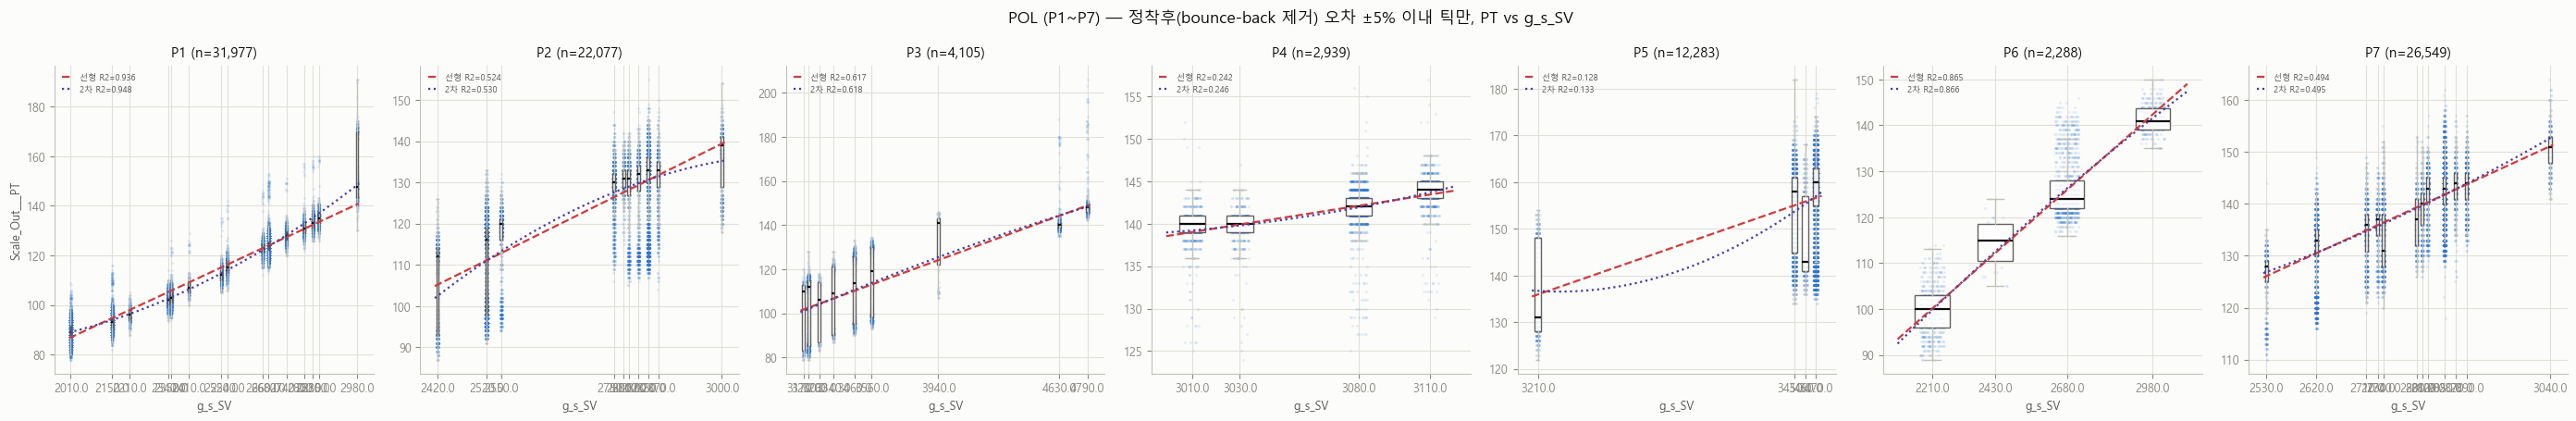

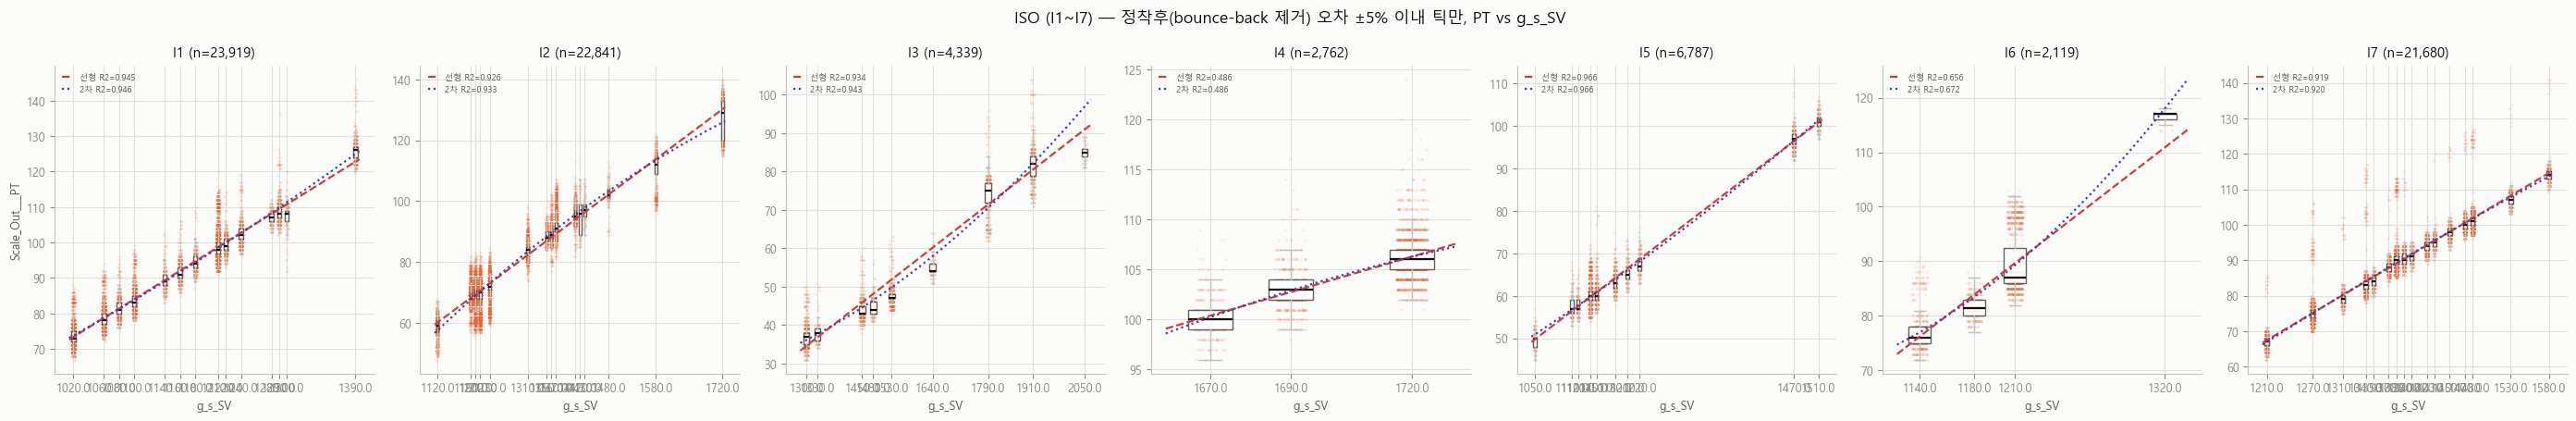

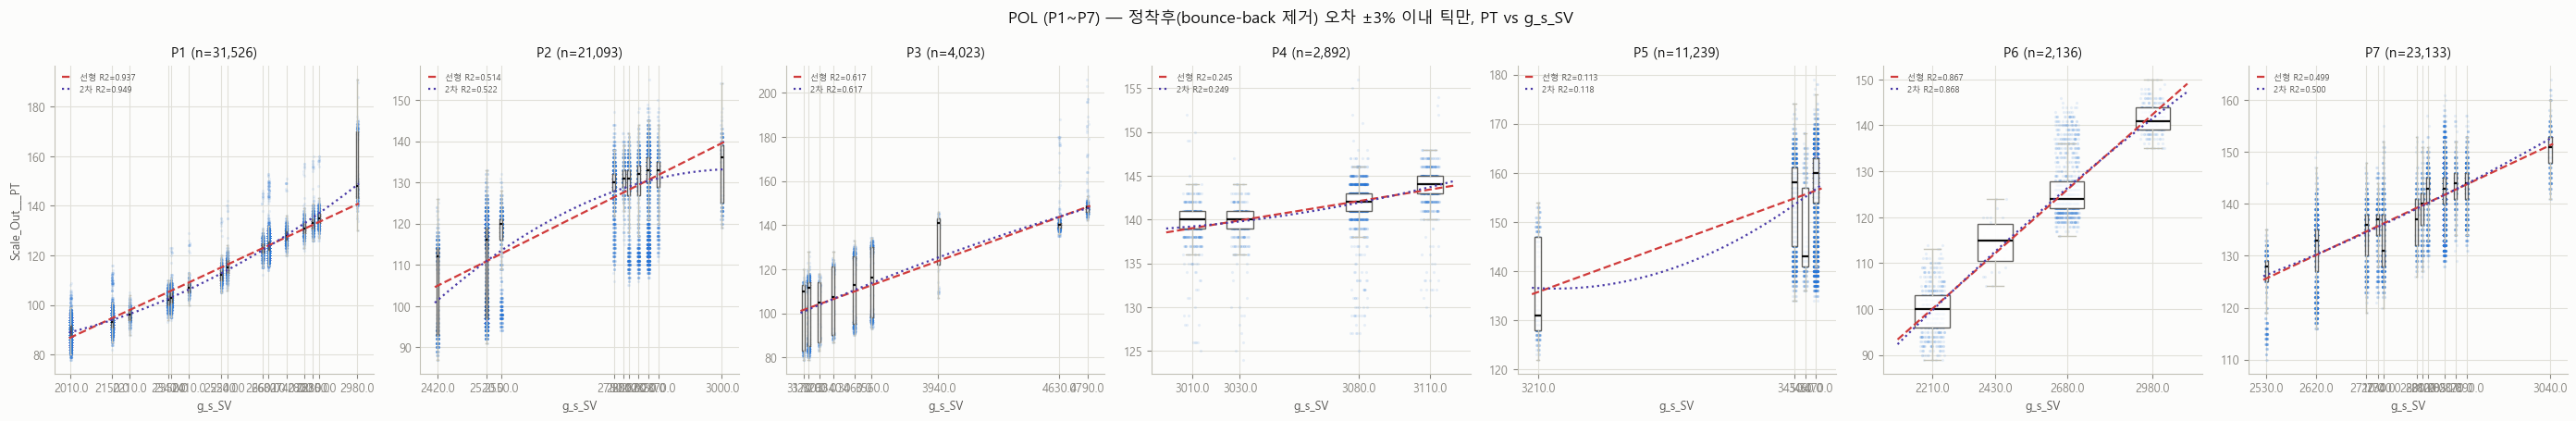

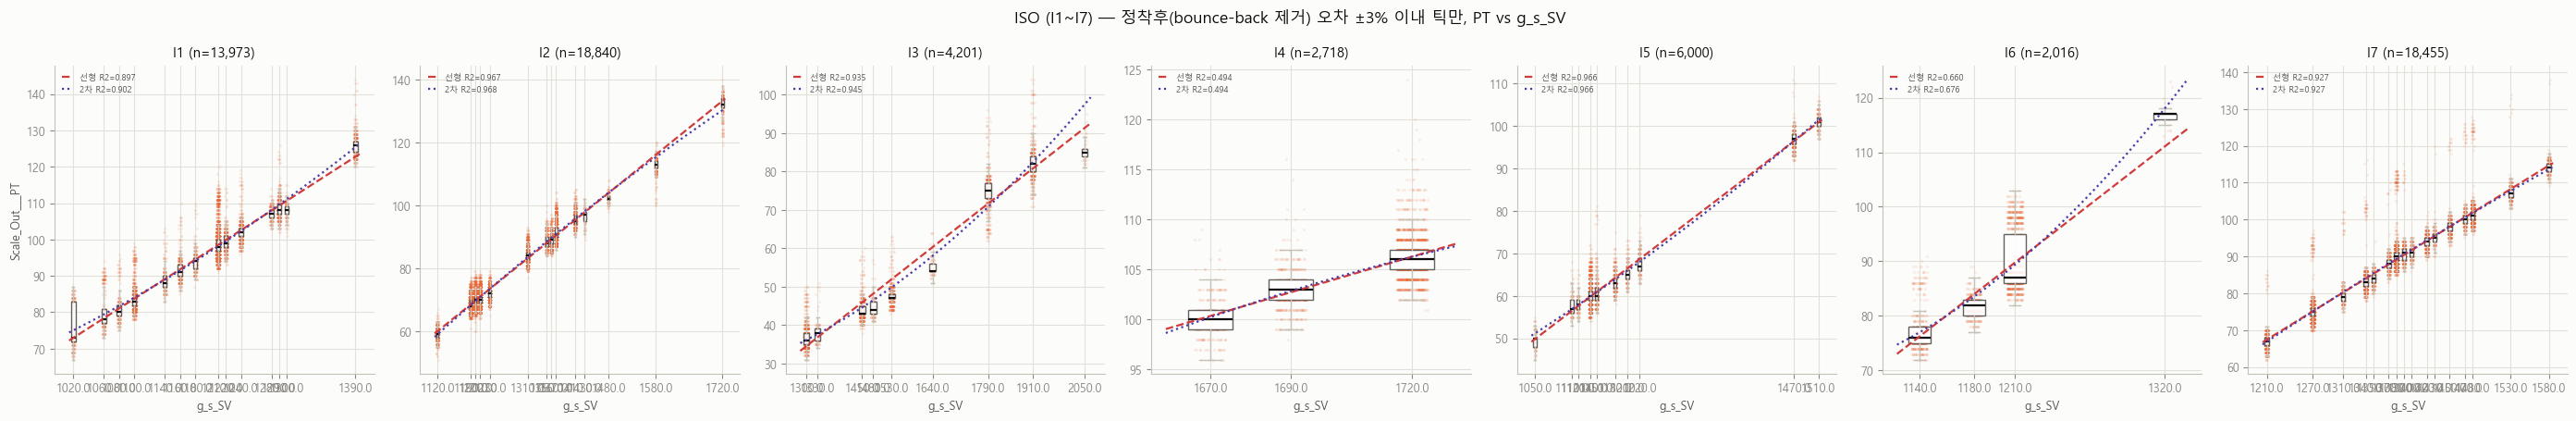

In [4]:
def r_squared(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def pt_sv_panel(ax, pid, band):
    tf = frames[pid]
    sub = band_settle_mask(tf, band)
    steady = sub[sub["Steady_B"]].dropna(subset=["SV", "PT"])
    cnt = steady["SV"].value_counts()
    levels = sorted(cnt[cnt >= MIN_SV_N].index)
    color = BLUE if pid.startswith("P") else ORANGE

    base = {"펌프": pid, "밴드": f"±{band}%", "n": len(steady)}
    if len(levels) < MIN_LEVELS_FOR_QUAD:
        ax.text(.5, .5, "표본 부족", ha="center", va="center", color=MUTED, transform=ax.transAxes)
        style(ax, title=f"{pid} (n={len(steady):,})")
        return {**base, "선형R2": np.nan, "이차R2": np.nan, "R2_개선": np.nan}

    steady_l = steady[steady["SV"].isin(levels)]
    gaps = np.diff(levels)
    width = max(float(np.min(gaps)) * 0.55, 3.0) if len(gaps) else 20.0

    rng = np.random.default_rng(0)
    jitter = rng.uniform(-1, 1, len(steady_l)) * width * 0.35
    ax.scatter(steady_l["SV"].values + jitter, steady_l["PT"].values, s=5, color=color,
               alpha=.10, lw=0, zorder=2)

    data = [steady_l[steady_l["SV"] == lv]["PT"].values for lv in levels]
    ax.boxplot(data, positions=levels, widths=width, patch_artist=True, showfliers=False,
              boxprops=dict(facecolor="white", alpha=.9, edgecolor=INK2, lw=1),
              medianprops=dict(color=INK, lw=1.6),
              whiskerprops=dict(color=AXIS), capprops=dict(color=AXIS), zorder=4)

    x, y = steady_l["SV"].values, steady_l["PT"].values
    lin = np.polyfit(x, y, 1)
    r2_lin = r_squared(y, np.polyval(lin, x))
    quad = np.polyfit(x, y, 2)
    r2_quad = r_squared(y, np.polyval(quad, x))

    xx = np.linspace(levels[0] - width, levels[-1] + width, 100)
    ax.plot(xx, np.polyval(lin, xx), color=RED, lw=1.6, ls="--", zorder=5, label=f"선형 R2={r2_lin:.3f}")
    ax.plot(xx, np.polyval(quad, xx), color=VIOLET, lw=1.6, ls=":", zorder=6, label=f"2차 R2={r2_quad:.3f}")
    ax.legend(frameon=False, fontsize=6.6, loc="upper left", labelcolor=INK2, handlelength=1.2)
    style(ax, title=f"{pid} (n={len(steady_l):,})", xlabel="g_s_SV")
    return {**base, "n": len(steady_l), "선형a": lin[0], "선형b": lin[1], "선형R2": r2_lin,
            "이차a": quad[0], "이차b": quad[1], "이차c": quad[2], "이차R2": r2_quad,
            "R2_개선": r2_quad - r2_lin}


def pt_sv_row(pump_list, band, title):
    fig, axes = plt.subplots(1, len(pump_list), figsize=(4.0 * len(pump_list), 4.6), sharey=False)
    rows = []
    for ax, pid in zip(np.atleast_1d(axes), pump_list):
        rows.append(pt_sv_panel(ax, pid, band))
    axes[0].set_ylabel("Scale_Out___PT", color=INK2, fontsize=9)
    fig.suptitle(title, color=INK, fontsize=12.5)
    fig.patch.set_facecolor(SURFACE)
    plt.tight_layout(); plt.show()
    return rows


fit_rows = []
for band in BANDS:
    fit_rows += pt_sv_row([f"P{n}" for n in ALL_PUMP_NUMS], band,
                          f"POL (P1~P7) — 정착후(bounce-back 제거) 오차 ±{band}% 이내 틱만, PT vs g_s_SV")
    fit_rows += pt_sv_row([f"I{n}" for n in ALL_PUMP_NUMS], band,
                          f"ISO (I1~I7) — 정착후(bounce-back 제거) 오차 ±{band}% 이내 틱만, PT vs g_s_SV")

---## 4. 선형 vs 2차 — 어느 쪽이 더 잘 맞나`R2_개선` = 2차R² − 선형R². 이게 크면(예: 0.02 이상) 2차가 확실히 더 잘 맞는다는뜻이고, 거의 0이면 굳이 2차를 쓸 이유가 없다(선형으로 충분).

In [5]:
fit_tbl = pd.DataFrame(fit_rows)
fit_tbl["판정"] = np.where(fit_tbl["R2_개선"].isna(), "-",
                   np.where(fit_tbl["R2_개선"] >= 0.02, "2차가 뚜렷이 나음",
                   np.where(fit_tbl["R2_개선"] >= 0.005, "2차가 약간 나음", "선형으로 충분")))
cols = ["펌프", "밴드", "n", "선형R2", "이차R2", "R2_개선", "판정"]
print(fit_tbl[cols].round(4).to_string(index=False))

print()
print("밴드별 판정 분포:")
print(fit_tbl.groupby("밴드")["판정"].value_counts().to_string())
print()
print(f"전체 선형 R² 평균: {fit_tbl['선형R2'].mean():.3f}   전체 2차 R² 평균: {fit_tbl['이차R2'].mean():.3f}")

펌프  밴드     n   선형R2   이차R2  R2_개선        판정
P1 ±5% 31977 0.9364 0.9483 0.0120 2차가 약간 나음
P2 ±5% 22077 0.5242 0.5303 0.0061 2차가 약간 나음
P3 ±5%  4105 0.6170 0.6177 0.0006   선형으로 충분
P4 ±5%  2939 0.2424 0.2463 0.0039   선형으로 충분
P5 ±5% 12283 0.1275 0.1328 0.0052 2차가 약간 나음
P6 ±5%  2288 0.8650 0.8659 0.0009   선형으로 충분
P7 ±5% 26549 0.4937 0.4950 0.0013   선형으로 충분
I1 ±5% 23919 0.9449 0.9461 0.0012   선형으로 충분
I2 ±5% 22841 0.9263 0.9335 0.0072 2차가 약간 나음
I3 ±5%  4339 0.9338 0.9431 0.0094 2차가 약간 나음
I4 ±5%  2762 0.4856 0.4865 0.0008   선형으로 충분
I5 ±5%  6787 0.9656 0.9661 0.0005   선형으로 충분
I6 ±5%  2119 0.6561 0.6723 0.0162 2차가 약간 나음
I7 ±5% 21680 0.9193 0.9197 0.0004   선형으로 충분
P1 ±3% 31526 0.9365 0.9486 0.0120 2차가 약간 나음
P2 ±3% 21093 0.5139 0.5219 0.0080 2차가 약간 나음
P3 ±3%  4023 0.6166 0.6175 0.0009   선형으로 충분
P4 ±3%  2892 0.2451 0.2494 0.0043   선형으로 충분
P5 ±3% 11239 0.1130 0.1177 0.0046   선형으로 충분
P6 ±3%  2136 0.8669 0.8679 0.0010   선형으로 충분
P7 ±3% 23133 0.4991 0.5000 0.0009   선형으로 충분
I1 ±3% 13973 0.8967 0.9016 0.004

---## 5. 정리- **bounce-back은 §2에서 확인한 대로 이미 제거된 데이터로 분석했다** — 정착후필터가  정의상 "그 뒤로 다시 안 벗어난" 틱만 남기므로, 증압 중 우연히 밴드를 스친 틱은  포함되지 않는다.- 안정구간(오차율 작은 케이스)만 놓고 보면 PT와 SV 사이에 **선형 관계가 뚜렷하다**  (§4 표의 `선형R2` 참고 — 대부분 0.5 이상, 일부는 0.9 이상).- **2차식을 추가해도 대부분 크게 나아지지 않는다** — `R2_개선`이 §4 표에서 대체로  작다면, 이 관계는 "곡선"이 아니라 "직선"으로 보는 게 맞다는 뜻이다. `판정` 열이  "2차가 뚜렷이 나음"으로 나온 펌프가 있다면 그건 예외로 따로 볼 만하다.- ±5%와 ±3% 밴드를 비교했을 때 R²가 크게 안 바뀌면, 이 관계가 안정구간을 얼마나  엄격하게 잡느냐에 민감하지 않다는 뜻이다.- P3/P4/P6/I3/I4/I6 처럼 가동량이 적은 펌프는 밴드를 ±3%로 좁히면 표본이 더  줄어서 "표본 부족"으로 나오거나 회귀가 불안정할 수 있다.